In [1]:
import pulp as pl
import networkx as nx

In [2]:
def get_m_degree(G):
    X = [0 for _ in range(0, len(G.nodes())+1)]
    Z = [0 for _ in range(0, len(G.nodes())+1)]
    max_j = 0
    for u in G.nodes(): X[G.degree(u)] += 1
    for j in range(len(G.nodes())-1, 0, -1): Z[j] = Z[j+1] + X[j]
    for j in range(1, len(G.nodes)):
        if Z[j-1] >= j:
            max_j = j
    return max_j

#### Choosing a random Graph

In [34]:
G = nx.random_regular_graph(d=3,n=6)

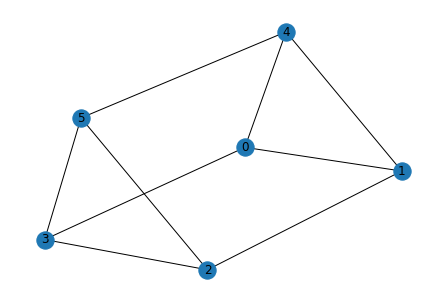

In [35]:
nx.draw(G, with_labels=True)

In [55]:
for v in G.nodes():
    for c in C:
        if(x_vars[v,c].value() == 1.0):
            print(v,c)

0 1
1 3
2 0
4 2
3 2
5 1


#### Model definition

In [116]:
b_chr_model = pl.LpProblem(name="b-chromatic-model")

#### Variables definition

In [117]:
n = len(G.nodes) #number of vertices
V = list(G.nodes)
c =  get_m_degree(G)#number of colours
C = range(c)

In [118]:
C

range(0, 4)

$x_{vc},z_{vc}\in \{0,1\} \hspace{1cm}\forall v\in V, \forall c\in C$

$d_c\in \{0,1\}\hspace{1cm}\forall c \in C$

In [119]:
x_vars = {(v,c):pl.LpVariable(
                             cat=pl.LpBinary,
                             name="x_{0}_{1}".format(v,c))
            for v in V for c in C}

z_vars = {(v,c):pl.LpVariable(
                             cat=pl.LpBinary,
                             name="z_{0}_{1}".format(v,c))
            for v in V for c in C}

d_vars = {c:pl.LpVariable(
                cat=pl.LpBinary,
                name="d_{0}".format(c))
             for c in C}

#### Constraints

$\sum_{c\in C}x_{vc}=1\hspace{1cm}\forall v\in V$

In [120]:
one_colour_constraint = {v:b_chr_model.addConstraint(
                            pl.LpConstraint(
                                e=pl.lpSum(x_vars[v,c] for c in C),
                                sense=pl.LpConstraintEQ,
                                rhs=1,
                                name="one_colour_{}".format(v))
                        ) for v in V}

$x_{vc}+x_{wc}\leq 1\hspace{1cm}\forall vw\in E, \forall c\in C$

In [121]:
diff_colour_per_edge_constraint = {(v,w,c):b_chr_model.addConstraint(
                                            pl.LpConstraint(
                                                e=x_vars[v,c]+x_vars[w,c],
                                                sense=pl.LpConstraintLE,
                                                rhs=1,
                                                name="diff_colour_{0}_{1}_{2}".format(v,w,c)
                                            )) 
                                   for v, w in G.edges for c in C}

$z_{vc}\leq \sum_{w\in N(v)}x_{wd}\hspace{1cm} \forall v\in V,\forall c,d\in C, c\neq d$ (is forcing us to use all the colours)

In [122]:
b_chromatic_vertex_constraint = {(v,c,d):b_chr_model.addConstraint(
                                            pl.LpConstraint(
                                                e=z_vars[v,c]-pl.lpSum(x_vars[w,d] for w in G.neighbors(v)),
                                                sense=pl.LpConstraintLE,
                                                rhs=0,
                                                name="b_chr_vertex_{0}_{1}_{2}".format(v,c,d)
                                            )
                                        )
                                 for v in V for c in C for d in C if c!=d}

$d_c\leq \sum_{v\in V}z_{vc}\hspace{1cm} c\in C$

In [123]:
b_chromatic_vertices_constraint = {c:b_chr_model.addConstraint(
                                        pl.LpConstraint(
                                            e=d_vars[c]-pl.lpSum(z_vars[v,c] for v in V),
                                            sense=pl.LpConstraintLE,
                                            rhs=0,
                                            name="b_chro_colour_{0}".format(c)
                                        )
                                    )
                                  for c in C}

$d_c\geq \sum_{v\in V}x_{vc}\hspace{1cm}\forall c\in C$

In [124]:
#every_colour_b_chromatic = {c:b_chr_model.addConstraint(
#                                        pl.LpConstraint(
#                                            e=pl.lpSum(x_vars[v,c] for v in V)/n-d_vars[c],
#                                            sense=pl.LpConstraintLE,
#                                            rhs=0,
#                                            name="every_colour_b_chro_{0}".format(c)
#                                        )
#                                    )
#                                  for c in C}

In [58]:
for c in C:
    print(c,d_vars[c].value())

0 1.0
1 0.0
2 0.0
3 1.0


In [60]:
for v in V:
    for c in C:
        print(v,c,z_vars[v,c].value())

0 0 0.0
0 1 0.0
0 2 0.0
0 3 0.0
1 0 0.0
1 1 0.0
1 2 0.0
1 3 1.0
2 0 1.0
2 1 0.0
2 2 0.0
2 3 0.0
4 0 0.0
4 1 0.0
4 2 0.0
4 3 0.0
3 0 0.0
3 1 0.0
3 2 0.0
3 3 0.0
5 0 0.0
5 1 0.0
5 2 0.0
5 3 0.0


#### Objective function

$\max \sum_{c\in C}d_c$

In [125]:
b_chromatic_number = pl.lpSum(d_vars[c] for c in C)

In [126]:
b_chr_model.sense = pl.LpMaximize
b_chr_model.setObjective(b_chromatic_number)

In [127]:
#b_chr_model.solve(solver=pl.get_solver("GUROBI_CMD"))
b_chr_model.solve()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/homebrew/Caskroom/miniforge/base/envs/.tests/lib/python3.10/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/ry/3v8_xnw15pd9mvfwjp4s44z80000gn/T/74adafafdb3c49a78db257532c7b07ba-pulp.mps max timeMode elapsed branch printingOptions all solution /var/folders/ry/3v8_xnw15pd9mvfwjp4s44z80000gn/T/74adafafdb3c49a78db257532c7b07ba-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 123 COLUMNS
At line 644 RHS
At line 763 BOUNDS
At line 816 ENDATA
Problem MODEL has 118 rows, 52 columns and 412 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 4 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 8 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 8 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 8 strengthened rows, 0 substitutions
Cgl0004I pr

1